In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import gplugins.tidy3d as gt
import gdsfactory as gf

from upvfab_design_tools import MMI_EME, DC_EME

# Constantes útiles
nm = 1e-3

## Part I. Design and Simulation of Individual Components 
### 1. Simulating Propagation Modes in SOI Waveguides (2 hours)


Steps:  
1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 
2. Simulate fundamental TE and TM modes. 
3. Extract effective index (n_eff) and group index (n_g) values. 

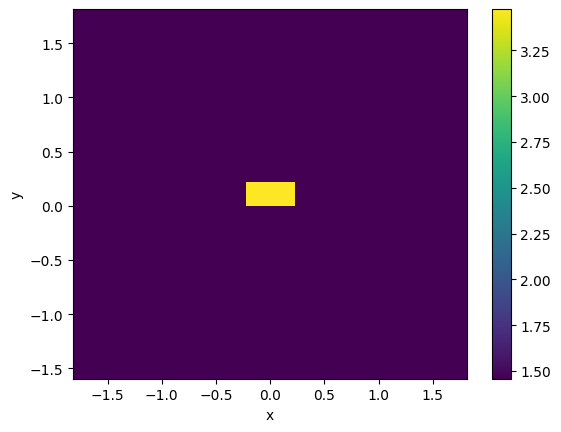

In [2]:
# PASO 1
waveguide = gt.modes.Waveguide(
    core_width=0.45,         
    core_thickness=0.22,    
    core_material="si",      
    clad_material="sio2",    
    wavelength=1.55,         
    num_modes=4,
    grid_resolution=20,      
    cache_path='.cache/',   
)
waveguide.plot_index()

2026-03-31 16:38:46.631 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6899bf2cf261b966.npz.


Text(0.5, 1.0, 'Modo Fundamental TE')

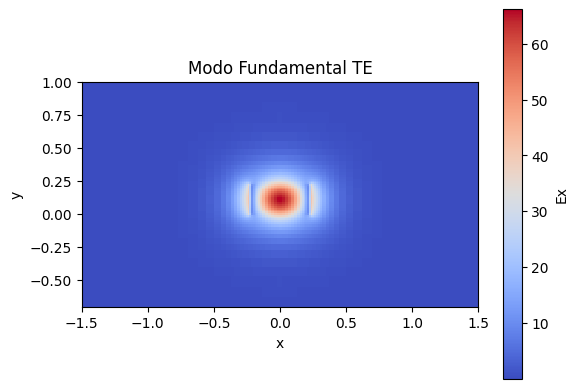

In [3]:
#PASO 2
waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo Fundamental TE') 

Text(0.5, 1.0, 'Modo Fundamental TM')

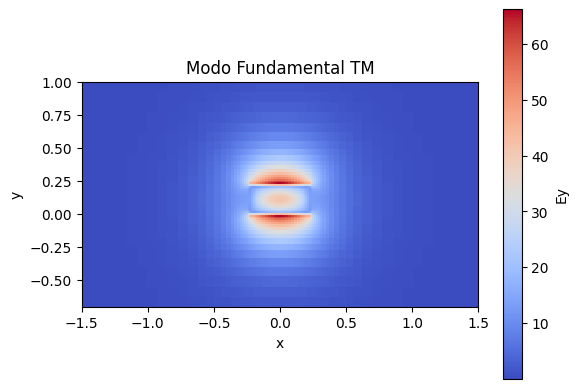

In [4]:
waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Modo Fundamental TM') 

In [5]:
 #PASO 3
waveguide.n_eff

array([2.38277127+6.50477980e-05j, 1.80504449+2.19670593e-04j,
       1.46868616+2.04881987e-04j, 1.43225807+2.18112239e-04j])

In [6]:
waveguide.fraction_tm

array([0.03557025, 0.93791301, 0.33863573, 0.00242617])

In [7]:
waveguide.fraction_te

array([0.96442975, 0.06208699, 0.66136427, 0.99757383])

In [ ]:
#PASO 3 PARA 1550nm
SOI = np.loadtxt('SOI-w450-h220-clad600.txt', skiprows=1, delimiter='\t')

wvl = SOI[:, 0]
neff_te = SOI[:, 3]

indice_central = np.where(np.isclose(wvl, 1.55))[0][0]

wvl_central = wvl[indice_central]
n_eff_central = neff_te[indice_central]

dn_eff = (neff_te[indice_central + 1] - neff_te[indice_central - 1]) / 2
delta_wvl = (wvl[indice_central + 1] - wvl[indice_central - 1]) / 2

dn_eff_dlambda = dn_eff / delta_wvl

n_g_te = n_eff_central - (wvl_central * dn_eff_dlambda)

print(f"n_eff TE a 1.55um: {n_eff_central}")
print(f"n_g TE calculado:  {n_g_te}")

n_eff TE a 1.55um: 2.35577
n_g TE calculado:  4.293269999999957


### 2. Designing Directional Couplers (2 hours) 
• Objective: Achieve coupling constants as shown in Figure 5(b). 
• Steps:  
1. Simulate directional couplers in GDSFactory. 
2. Sweep different gap values and coupling lengths. 
3. Extract coupling coefficients (e.g., 0.5, 0.3, 0.23, etc.).

In [25]:
#PASO 1
w = 0.45
h = 0.22
wvl = 1.55
gap_fijo = 0.4

coupler = gt.modes.WaveguideCoupler(
    core_width=(w,w),
    core_thickness=h,
    core_material="si",
    clad_material="sio2",
    gap=gap_fijo,
    wavelength=wvl,
    num_modes=2,
    grid_resolution=20,
    cache_path='.cache/'
)

coupler.plot()

AttributeError: 'WaveguideCoupler' object has no attribute 'plot'

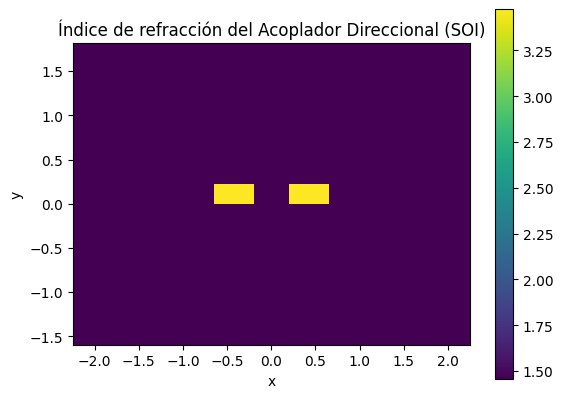

2026-03-23 17:00:07.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_d7d28029e1f4bec7.npz.


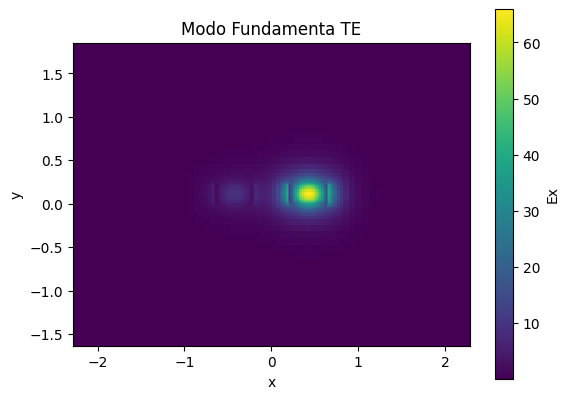

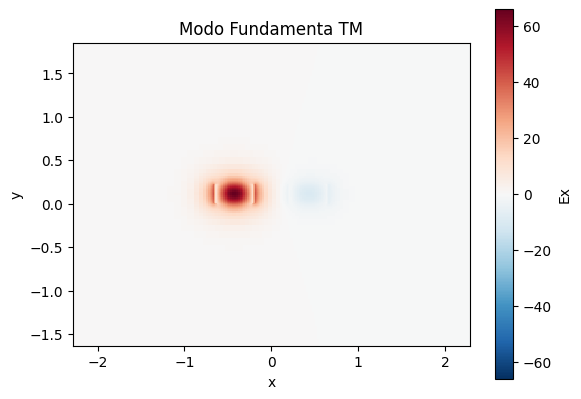

In [28]:
import gplugins.tidy3d as gt
import matplotlib.pyplot as plt

w = 0.45
h = 0.22
wvl = 1.55
gap_fijo = 0.4

dcoupler_cs = gt.modes.WaveguideCoupler(
    core_width=(w, w),   
    slab_thickness=0 * nm,    
    core_thickness=h,      
    gap=gap_fijo,            
    core_material='si',      
    clad_material='sio2',   
    wavelength=wvl,
    num_modes=4,              
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20
)

dcoupler_cs.plot_index()
plt.title("Índice de refracción del Acoplador Direccional (SOI)")
plt.show()

dcoupler_cs.plot_field(mode_index=0, field_name='Ex', value='real')
plt.title("Modo Fundamenta TE")
plt.show()

dcoupler_cs.plot_field(mode_index=1, field_name='Ex', value='real')
plt.title("Modo Fundamenta TM")
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\k'
<>:42: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_51470/236378981.py:42: SyntaxWarning: invalid escape sequence '\k'
  plt.ylabel('Coeficiente de acoplo cruzado ($\kappa^2$)')
/home/mjulben/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the

2026-03-23 16:50:00.117 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_e0ddedf4d2ad1493.npz.
Para un Gap de 0.4 um, L_pi (acoplo 100%) es: 35.7108 um

Longitudes de acoplo calculadas para k^2
Objetivo k^2 = 0.05 se necesita L = 5.126863187435748 um
Objetivo k^2 = 0.17 se necesita L = 9.66177304522331 um
Objetivo k^2 = 0.23 se necesita L = 11.371175087016924 um
Objetivo k^2 = 0.3 se necesita L = 13.177636313948804 um
Objetivo k^2 = 0.5 se necesita L = 17.85538609274932 um


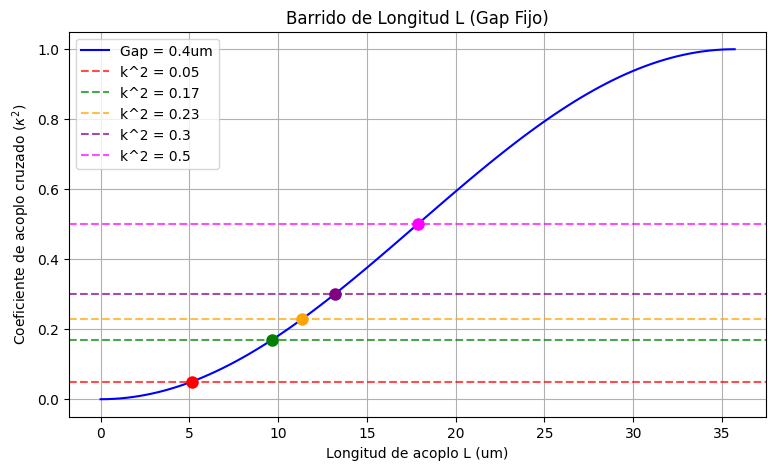

In [22]:
# PASO 2: Fijando el gap y barriendo la L de acoplo
w = 0.45
h = 0.22
wvl = 1.55
gap_fijo = 0.4

coupler = gt.modes.WaveguideCoupler(
    core_width=(w,w),
    core_thickness=h,
    core_material="si",
    clad_material="sio2",
    gap=gap_fijo,
    wavelength=wvl,
    num_modes=2,
    grid_resolution=20,
    cache_path='.cache/'
)

n_even = coupler.n_eff[0].real
n_odd  = coupler.n_eff[1].real

L_pi = wvl / (2 * (n_even - n_odd))
print(f"Para un Gap de {gap_fijo} um, L_pi (acoplo 100%) es: {L_pi:.4f} um\n")

L_sweep = np.linspace(0, L_pi, 100)
kappa_cuad = np.sin(np.pi * L_sweep / (2 * L_pi))**2

plt.figure(figsize=(9, 5))
plt.plot(L_sweep, kappa_cuad, color='blue', label=f'Gap = {gap_fijo}um')

objetivos = [0.05,0.17,0.23,0.3,0.5]
colores = ['red', 'green', 'orange', 'purple','fuchsia']

print("Longitudes de acoplo calculadas para k^2")
for obj, col in zip(objetivos, colores):
    L_exacta = (2 * L_pi / np.pi) * np.arcsin(np.sqrt(obj))
    print(f"Objetivo k^2 = {obj} se necesita L = {L_exacta} um")
    plt.axhline(obj, color=col, linestyle='--', alpha=0.7, label=f'k^2 = {obj}')
    plt.plot(L_exacta, obj, marker='o', color=col, markersize=8)

plt.xlabel('Longitud de acoplo L (um)')
plt.ylabel('Coeficiente de acoplo cruzado ($\kappa^2$)')
plt.title('Barrido de Longitud L (Gap Fijo)')
plt.legend()
plt.grid(True)
plt.show()